In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.sparse import issparse

In [3]:
from sklearn.linear_model import LinearRegression, LogisticRegression

In [4]:
data_file = r"D:\placement.csv"
df = pd.read_csv(data_file)

In [5]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [8]:
df.isnull().sum()

cgpa       0
package    0
dtype: int64

In [9]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Packages(in lpa)')

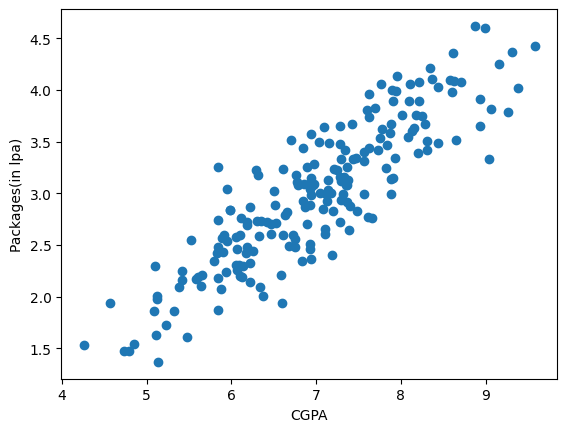

In [10]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Packages(in lpa)')

In [21]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [23]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [25]:
lr = LinearRegression()

In [26]:
lr.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

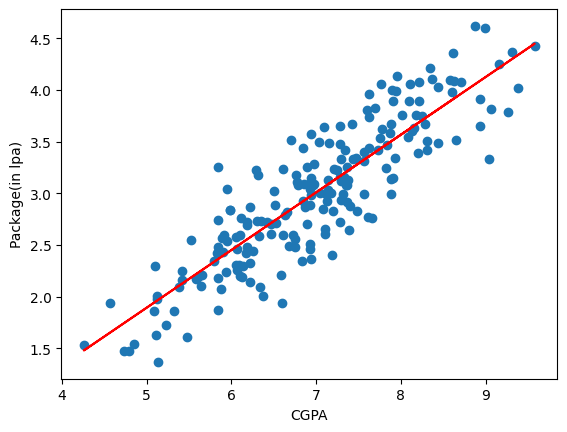

In [27]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [29]:
y_pred = lr.predict(X_test)

In [30]:
mean_absolute_error(y_test,y_pred)

np.float64(0.2884710931878175)

In [31]:
mean_squared_error(y_test,y_pred)

np.float64(0.12129235313495527)

In [32]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.34827051717731616)

In [33]:
r2_score(y_test,y_pred)

np.float64(0.780730147510384)

In [34]:
# Applying L1 and L2 regularization
from sklearn.linear_model import Ridge, Lasso

In [35]:
L1  = Lasso()

In [36]:
L1.fit(X_train,y_train)


Lasso()

In [37]:
y_lasso_pred = L1.predict(X_test)

In [38]:
mse_lasso = mean_squared_error(y_test, y_lasso_pred)

In [43]:
print(mse_lasso)

0.5547200664062499


In [ ]:
L2 = Ridge()
L2.fit(X_train,y_train)
y_ridge_pred = L2.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_ridge_pred)
print(mse_ridge)

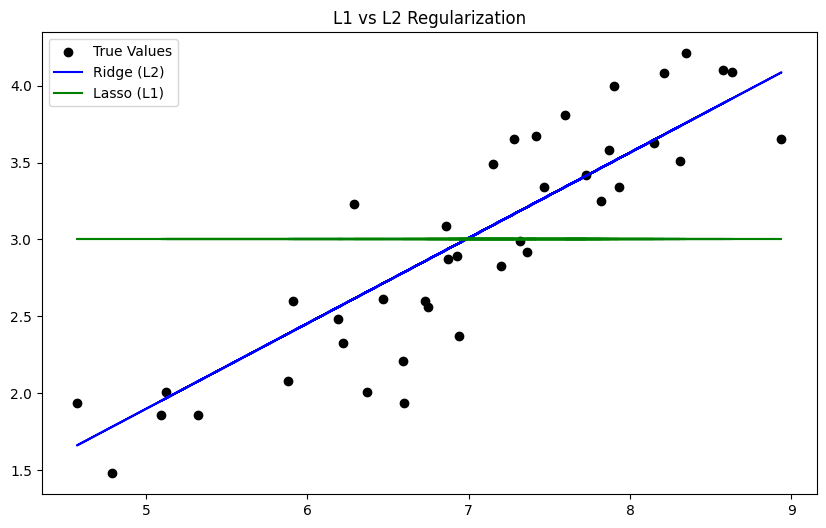

In [42]:
# Plot L1 vs L2
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black', label='True Values')
plt.plot(X_test, y_ridge_pred, label='Ridge (L2)', color='blue')
plt.plot(X_test, y_lasso_pred, label='Lasso (L1)', color='green')
plt.legend()
plt.title("L1 vs L2 Regularization")
plt.show()